In [4]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
breast_cancer = load_breast_cancer()

In [6]:
df = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
df['target'] = breast_cancer.target

In [7]:
plt.style.use('fivethirtyeight')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

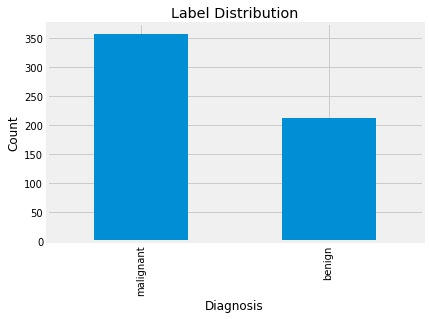

In [9]:
data  = df 
data['target'].replace({0: 'benign', 1: 'malignant'}, inplace=True)


label_counts = data['target'].value_counts()

label_counts.plot(kind='bar')
plt.title('Label Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

<AxesSubplot: xlabel='mean symmetry', ylabel='worst radius'>

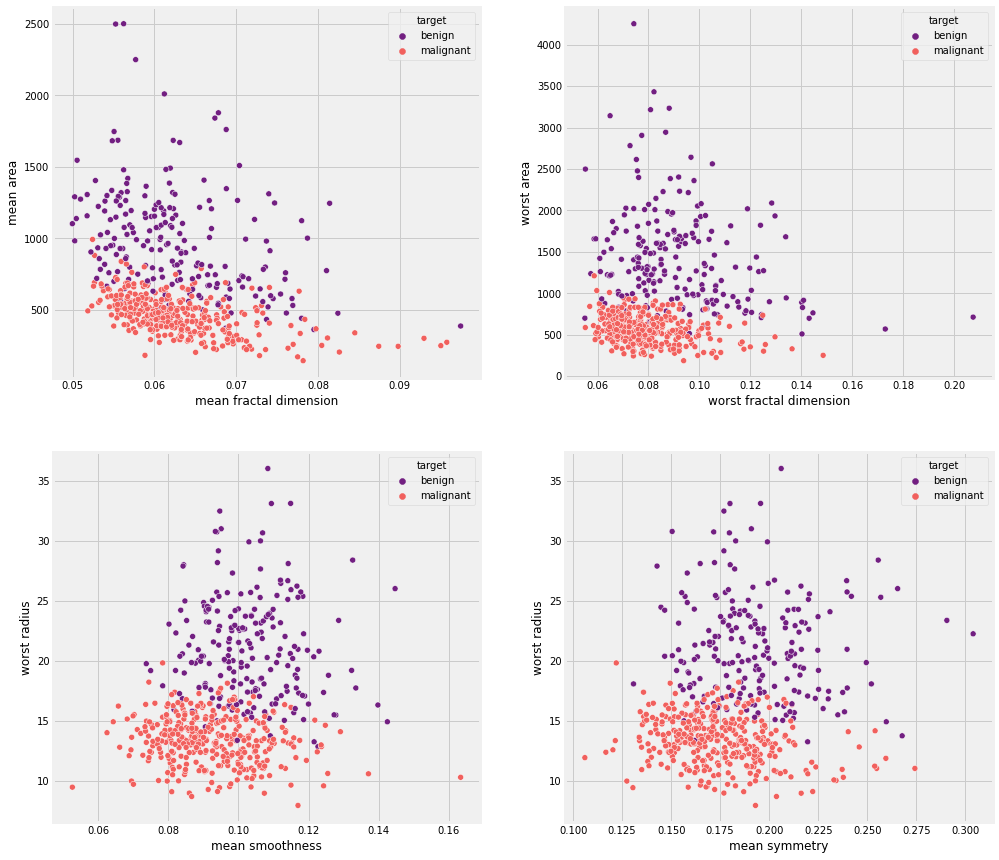

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(15, 15))
sns.scatterplot(x='mean fractal dimension', y='mean area', hue="target",
                data=df, ax=ax[0][0], palette='magma')
sns.scatterplot(x='worst fractal dimension', y='worst area', hue="target",
                data=df, ax=ax[0][1], palette='magma')
sns.scatterplot(x='mean smoothness', y='worst radius', hue="target",
                data=df, ax=ax[1][0], palette='magma')
sns.scatterplot(x='mean symmetry', y='worst radius', hue="target",
                data=df, ax=ax[1][1], palette='magma')

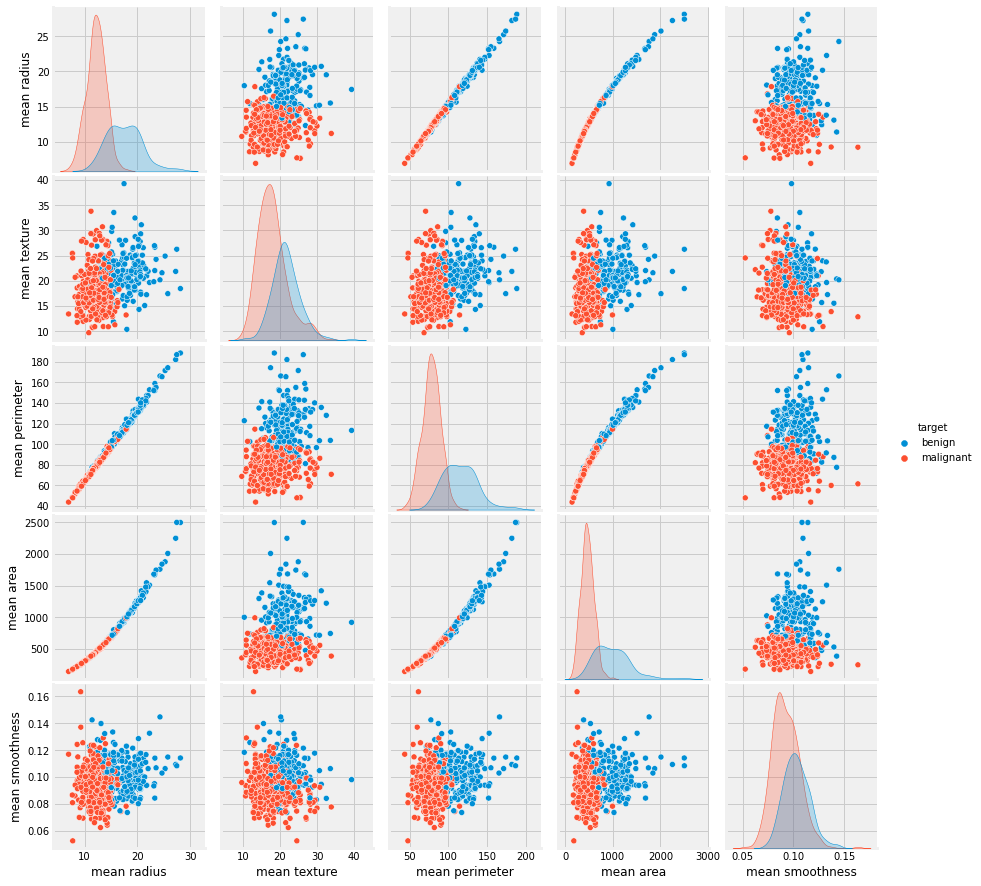

In [11]:
sns.pairplot(df, hue='target', vars=['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness'])
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df['target'], test_size=0.3, random_state=42)

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}".format(accuracy))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.96
Confusion Matrix:
[[ 59   4]
 [  3 105]]
Classification Report:
              precision    recall  f1-score   support

      benign       0.95      0.94      0.94        63
   malignant       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

